# Ensemble NN + XGBoost

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_rank
from optuna.visualization import plot_slice
from optuna.visualization import plot_timeline

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Data Loading


In [4]:
# Load the data
train_x_df = pd.read_csv('../../data/X_train.csv')
train_y_df = pd.read_csv('../../data/Y_train.csv')

test_x_df = pd.read_csv('../../data/X_test.csv')

C:\Users\tomhi\AppData\Local\Temp\ipykernel_21036\3151947916.py:2: DtypeWarning: Columns (0: item21, 1: item22, 2: item23, 3: item24, 4: make21, 5: make22, 6: make23, 7: make24, 8: model21, 9: model22, 10: model23, 11: model24, 12: goods_code1, 13: goods_code8, 14: goods_code9, 15: goods_code10, 16: goods_code11, 17: goods_code12, 18: goods_code13, 19: goods_code14, 20: goods_code15, 21: goods_code16, 22: goods_code17, 23: goods_code18, 24: goods_code19, 25: goods_code20, 26: goods_code21, 27: goods_code22, 28: goods_code23, 29: goods_code24) have mixed types. Specify dtype option on import or set low_memory=False.
  train_x_df = pd.read_csv('../../data/X_train.csv')
C:\Users\tomhi\AppData\Local\Temp\ipykernel_21036\3151947916.py:5: DtypeWarning: Columns (0: item20, 1: item21, 2: item22, 3: item23, 4: item24, 5: make20, 6: make21, 7: make22, 8: make23, 9: make24, 10: model20, 11: model21, 12: model22, 13: model23, 14: model24, 15: goods_code1, 16: goods_code10, 17: goods_code11, 18: go

### Get Categorical features

In [5]:
item_cols = [f'item{i}' for i in range(1, 25)]
make_cols = [f'make{i}' for i in range(1, 25)]
goods_cols = [f'goods_code{i}' for i in range(1, 25)]

cat_cols = item_cols + make_cols + goods_cols

print(cat_cols)

train_x_df[cat_cols].head()

['item1', 'item2', 'item3', 'item4', 'item5', 'item6', 'item7', 'item8', 'item9', 'item10', 'item11', 'item12', 'item13', 'item14', 'item15', 'item16', 'item17', 'item18', 'item19', 'item20', 'item21', 'item22', 'item23', 'item24', 'make1', 'make2', 'make3', 'make4', 'make5', 'make6', 'make7', 'make8', 'make9', 'make10', 'make11', 'make12', 'make13', 'make14', 'make15', 'make16', 'make17', 'make18', 'make19', 'make20', 'make21', 'make22', 'make23', 'make24', 'goods_code1', 'goods_code2', 'goods_code3', 'goods_code4', 'goods_code5', 'goods_code6', 'goods_code7', 'goods_code8', 'goods_code9', 'goods_code10', 'goods_code11', 'goods_code12', 'goods_code13', 'goods_code14', 'goods_code15', 'goods_code16', 'goods_code17', 'goods_code18', 'goods_code19', 'goods_code20', 'goods_code21', 'goods_code22', 'goods_code23', 'goods_code24']


,item1,item2,item3,item4,item5,item6,item7,item8,item9,item10,...,goods_code15,goods_code16,goods_code17,goods_code18,goods_code19,goods_code20,goods_code21,goods_code22,goods_code23,goods_code24
0,COMPUTERS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,COMPUTER PERIPHERALS ACCESSORIES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TELEVISIONS HOME CINEMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,COMPUTERS,COMPUTER PERIPHERALS ACCESSORIES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TELEVISIONS HOME CINEMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Fill NaN values with a flag string

In [6]:
train_x_df[cat_cols] = train_x_df[cat_cols].fillna("NONE")
test_x_df[cat_cols] = test_x_df[cat_cols].fillna("NONE")

train_x_df[cat_cols].head()

,item1,item2,item3,item4,item5,item6,item7,item8,item9,item10,...,goods_code15,goods_code16,goods_code17,goods_code18,goods_code19,goods_code20,goods_code21,goods_code22,goods_code23,goods_code24
0,COMPUTERS,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,...,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE
1,COMPUTER PERIPHERALS ACCESSORIES,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,...,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE
2,TELEVISIONS HOME CINEMA,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,...,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE
3,COMPUTERS,COMPUTER PERIPHERALS ACCESSORIES,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,...,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE
4,TELEVISIONS HOME CINEMA,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,...,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE


### Create vocabulary for each type of category (string to number mapping)

In [7]:
def create_shared_vocab(train_df, test_df, cols):

    all_values = pd.concat([
        train_df[col]
        for col in cols
    ] + [
        test_df[col]
        for col in cols
    ]).astype(str)

    unique_values = sorted(
        set(all_values) - {"NONE"}
    )

    vocab = {
        value: idx + 1
        for idx, value in enumerate(unique_values)
    }

    vocab["NONE"] = 0

    return vocab

item_vocab = create_shared_vocab(
    train_x_df,
    test_x_df,
    item_cols
)

make_vocab = create_shared_vocab(
    train_x_df,
    test_x_df,
    make_cols
)

goods_vocab = create_shared_vocab(
    train_x_df,
    test_x_df,
    goods_cols
)

print(item_vocab)

{'2HP ELITEBOOK 850V6': 1, '2LOGITECH PEBBLE M350 BLUETOOTH MOUSE': 2, '2MICROSOFT OFFICE HOME AND STUDENT 2019,': 3, '2TARGUS GEOLITE ESSENTIAL CASE': 4, '2TOSHIBA PORTABLE HARD DRIVE': 5, '6  SPACE GREY 32GB': 6, 'AERIALS REMOTE CONTROLS': 7, 'APPLE PRODUCTDESCRIPTION': 8, 'APPLE S': 9, 'AUDIO ACCESSORIES': 10, 'BABY & CHILD TRAVEL': 11, 'BABY CHANGING': 12, 'BABY CHILD TRAVEL': 13, 'BABY FEEDING': 14, 'BABY PLAY EQUIPMENT': 15, 'BABYWEAR': 16, 'BAGS & CARRY CASES': 17, 'BAGS CARRY CASES': 18, 'BAGS WALLETS ACCESSORIES': 19, 'BAGS, WALLETS & ACCESSORIES': 20, 'BARBECUES & ACCESSORIES': 21, 'BARBECUES ACCESSORIES': 22, 'BARWARE': 23, 'BATH & BODYCARE': 24, 'BATH BODYCARE': 25, 'BATH LINEN': 26, 'BATHROOM': 27, 'BATHROOM ACCESSORIES': 28, 'BATHROOM FIXTURES': 29, 'BED LINEN': 30, 'BEDROOM FURNITURE': 31, 'BLANK MEDIA & MEDIA STORAGE': 32, 'BLANK MEDIA MEDIA STORAGE': 33, 'BOOKS': 34, 'BOYSWEAR': 35, 'CABLES & ADAPTERS': 36, 'CABLES ADAPTERS': 37, 'CARPETS RUGS FLOORING': 38, 'CARPETS, 

### Encode all categorical columns using the vocabs

In [8]:
def encode_columns(df, cols, vocab):

    for col in cols:

        df[col] = (
            df[col]
            .astype(str)
            .map(vocab)
            .fillna(0)
            .astype(int)
        )

encode_columns(train_x_df,item_cols,item_vocab)
encode_columns(test_x_df,item_cols,item_vocab)
encode_columns(train_x_df,make_cols,make_vocab)
encode_columns(test_x_df,make_cols,make_vocab)
encode_columns(train_x_df,goods_cols,goods_vocab)
encode_columns(test_x_df,goods_cols,goods_vocab)

train_x_df[cat_cols].head()

,item1,item2,item3,item4,item5,item6,item7,item8,item9,item10,...,goods_code15,goods_code16,goods_code17,goods_code18,goods_code19,goods_code20,goods_code21,goods_code22,goods_code23,goods_code24
0,49,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,47,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,162,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,49,47,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,162,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
embedding_sizes = {
    "item": len(item_vocab),
    "make": len(make_vocab),
    "goods": len(goods_vocab)
}

print(embedding_sizes)

{'item': 178, 'make': 888, 'goods': 17029}


### Identify and clean numeric columns (replace NaN with 0)

In [10]:
# Identify numeric columns
numeric_cols = [
    col for col in train_x_df.columns
    if col not in cat_cols + ['ID'] + ['Nb_of_items'] + ['model' + str(i) for i in range(1, 25)]
]

print(numeric_cols)

train_x_df[numeric_cols].head()

['cash_price1', 'cash_price2', 'cash_price3', 'cash_price4', 'cash_price5', 'cash_price6', 'cash_price7', 'cash_price8', 'cash_price9', 'cash_price10', 'cash_price11', 'cash_price12', 'cash_price13', 'cash_price14', 'cash_price15', 'cash_price16', 'cash_price17', 'cash_price18', 'cash_price19', 'cash_price20', 'cash_price21', 'cash_price22', 'cash_price23', 'cash_price24', 'Nbr_of_prod_purchas1', 'Nbr_of_prod_purchas2', 'Nbr_of_prod_purchas3', 'Nbr_of_prod_purchas4', 'Nbr_of_prod_purchas5', 'Nbr_of_prod_purchas6', 'Nbr_of_prod_purchas7', 'Nbr_of_prod_purchas8', 'Nbr_of_prod_purchas9', 'Nbr_of_prod_purchas10', 'Nbr_of_prod_purchas11', 'Nbr_of_prod_purchas12', 'Nbr_of_prod_purchas13', 'Nbr_of_prod_purchas14', 'Nbr_of_prod_purchas15', 'Nbr_of_prod_purchas16', 'Nbr_of_prod_purchas17', 'Nbr_of_prod_purchas18', 'Nbr_of_prod_purchas19', 'Nbr_of_prod_purchas20', 'Nbr_of_prod_purchas21', 'Nbr_of_prod_purchas22', 'Nbr_of_prod_purchas23', 'Nbr_of_prod_purchas24']


,cash_price1,cash_price2,cash_price3,cash_price4,cash_price5,cash_price6,cash_price7,cash_price8,cash_price9,cash_price10,...,Nbr_of_prod_purchas15,Nbr_of_prod_purchas16,Nbr_of_prod_purchas17,Nbr_of_prod_purchas18,Nbr_of_prod_purchas19,Nbr_of_prod_purchas20,Nbr_of_prod_purchas21,Nbr_of_prod_purchas22,Nbr_of_prod_purchas23,Nbr_of_prod_purchas24
0,889.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,409.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1399.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,689.0,119.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1199.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Clean numberic columns by converting to numeric and filling NaNs with 0
train_x_df[numeric_cols] = train_x_df[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
test_x_df[numeric_cols] = test_x_df[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

train_x_df[numeric_cols].head()

,cash_price1,cash_price2,cash_price3,cash_price4,cash_price5,cash_price6,cash_price7,cash_price8,cash_price9,cash_price10,...,Nbr_of_prod_purchas15,Nbr_of_prod_purchas16,Nbr_of_prod_purchas17,Nbr_of_prod_purchas18,Nbr_of_prod_purchas19,Nbr_of_prod_purchas20,Nbr_of_prod_purchas21,Nbr_of_prod_purchas22,Nbr_of_prod_purchas23,Nbr_of_prod_purchas24
0,889.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,409.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1399.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,689.0,119.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1199.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Add aggregated numeric values (like average item price)

In [12]:
qty_cols = [f'Nbr_of_prod_purchas{i}' for i in range(1, 25)]

price_cols = [f'cash_price{i}' for i in range(1, 25)]

train_x_df['total_item_count'] = train_x_df[qty_cols].sum(axis=1)
train_x_df['total_price'] = train_x_df[price_cols].sum(axis=1)
train_x_df['max_price'] = train_x_df[price_cols].max(axis=1)
train_x_df['mean_price'] = train_x_df[price_cols].sum(axis=1) / train_x_df['total_item_count']

test_x_df['total_item_count'] = test_x_df[qty_cols].sum(axis=1)
test_x_df['total_price'] = test_x_df[price_cols].sum(axis=1)
test_x_df['max_price'] = test_x_df[price_cols].max(axis=1)
test_x_df['mean_price'] = test_x_df[price_cols].sum(axis=1) / test_x_df['total_item_count']

# Refresh numeric cols list to include new features
numeric_cols = [
    col for col in train_x_df.columns
    if col not in cat_cols + ['ID'] + ['Nb_of_items'] + ['model' + str(i) for i in range(1, 25)]
]

print(numeric_cols)

train_x_df[numeric_cols].head()

['cash_price1', 'cash_price2', 'cash_price3', 'cash_price4', 'cash_price5', 'cash_price6', 'cash_price7', 'cash_price8', 'cash_price9', 'cash_price10', 'cash_price11', 'cash_price12', 'cash_price13', 'cash_price14', 'cash_price15', 'cash_price16', 'cash_price17', 'cash_price18', 'cash_price19', 'cash_price20', 'cash_price21', 'cash_price22', 'cash_price23', 'cash_price24', 'Nbr_of_prod_purchas1', 'Nbr_of_prod_purchas2', 'Nbr_of_prod_purchas3', 'Nbr_of_prod_purchas4', 'Nbr_of_prod_purchas5', 'Nbr_of_prod_purchas6', 'Nbr_of_prod_purchas7', 'Nbr_of_prod_purchas8', 'Nbr_of_prod_purchas9', 'Nbr_of_prod_purchas10', 'Nbr_of_prod_purchas11', 'Nbr_of_prod_purchas12', 'Nbr_of_prod_purchas13', 'Nbr_of_prod_purchas14', 'Nbr_of_prod_purchas15', 'Nbr_of_prod_purchas16', 'Nbr_of_prod_purchas17', 'Nbr_of_prod_purchas18', 'Nbr_of_prod_purchas19', 'Nbr_of_prod_purchas20', 'Nbr_of_prod_purchas21', 'Nbr_of_prod_purchas22', 'Nbr_of_prod_purchas23', 'Nbr_of_prod_purchas24', 'total_item_count', 'total_price'

C:\Users\tomhi\AppData\Local\Temp\ipykernel_21036\3222992749.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_x_df['total_item_count'] = train_x_df[qty_cols].sum(axis=1)
C:\Users\tomhi\AppData\Local\Temp\ipykernel_21036\3222992749.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_x_df['total_price'] = train_x_df[price_cols].sum(axis=1)
C:\Users\tomhi\AppData\Local\Temp\ipykernel_21036\3222992749.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

,cash_price1,cash_price2,cash_price3,cash_price4,cash_price5,cash_price6,cash_price7,cash_price8,cash_price9,cash_price10,...,Nbr_of_prod_purchas19,Nbr_of_prod_purchas20,Nbr_of_prod_purchas21,Nbr_of_prod_purchas22,Nbr_of_prod_purchas23,Nbr_of_prod_purchas24,total_item_count,total_price,max_price,mean_price
0,889.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,889.0,889.0,889.0
1,409.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,409.0,409.0,409.0
2,1399.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1399.0,1399.0,1399.0
3,689.0,119.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,808.0,689.0,404.0
4,1199.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1199.0,1199.0,1199.0


### Scaling / Normalisation

In [13]:
for col in numeric_cols:

    train_x_df[col] = np.log1p(train_x_df[col])
    test_x_df[col] = np.log1p(test_x_df[col])

train_x_df[numeric_cols].head()

,cash_price1,cash_price2,cash_price3,cash_price4,cash_price5,cash_price6,cash_price7,cash_price8,cash_price9,cash_price10,...,Nbr_of_prod_purchas19,Nbr_of_prod_purchas20,Nbr_of_prod_purchas21,Nbr_of_prod_purchas22,Nbr_of_prod_purchas23,Nbr_of_prod_purchas24,total_item_count,total_price,max_price,mean_price
0,6.791221,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,6.791221,6.791221,6.791221
1,6.016157,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,6.016157,6.016157,6.016157
2,7.244228,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,7.244228,7.244228,7.244228
3,6.536692,4.787492,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.098612,6.695799,6.536692,6.003887
4,7.090077,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.693147,7.090077,7.090077,7.090077


### Convert to Tensors

In [14]:
import torch

X_cat = torch.tensor(
    train_x_df[cat_cols].values,
    dtype=torch.long
)

X_cat_test = torch.tensor(
    test_x_df[cat_cols].values,
    dtype=torch.long
)

X_num = torch.tensor(
    train_x_df[numeric_cols].values,
    dtype=torch.float32
)

X_num_test = torch.tensor(
    test_x_df[numeric_cols].values,
    dtype=torch.float32
)

y = train_y_df["fraud_flag"].values

y_tensor = torch.tensor(
    y,
    dtype=torch.float32
)

print(X_cat.shape)
print(X_num.shape)
print(y_tensor.shape)

print(X_cat[:1])
print(X_num[:1])

torch.Size([92790, 72])
torch.Size([92790, 52])
torch.Size([92790])
tensor([[   49,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,    34,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0, 12760,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0]])
tensor([[6.7912, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.6931, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.000

### Train / Validation Split

In [15]:
from sklearn.model_selection import train_test_split

X_cat_train, X_cat_val, X_num_train, X_num_val, y_train, y_val = train_test_split(
    X_cat, X_num, y_tensor, test_size=0.15, random_state=42
)

print(type(y_val))
print(np.shape(y_val))
print(y_val[:95])

<class 'torch.Tensor'>
torch.Size([13919])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 1.])


### Create Dataset class

In [16]:
from torch.utils.data import Dataset

class FraudDataset(Dataset):

    def __init__(self, X_cat, X_num, y=None):

        self.X_cat = X_cat
        self.X_num = X_num
        self.y = y

    def __len__(self):
        return len(self.X_cat)

    def __getitem__(self, idx):

        if self.y is not None:
            return (
                self.X_cat[idx],
                self.X_num[idx],
                self.y[idx]
            )

        return (
            self.X_cat[idx],
            self.X_num[idx]
        )

### Create the Datasets and Dataloaders

In [17]:
train_dataset = FraudDataset(
    X_cat_train,
    X_num_train,
    y_train
)

val_dataset = FraudDataset(
    X_cat_val,
    X_num_val,
    y_val
)

test_dataset = FraudDataset(
    X_cat_test,
    X_num_test
)

### Define Embedding Layers and flexible Neural Network

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import average_precision_score

class FraudModel(nn.Module):

    def __init__(
        self,
        embedding_sizes,
        n_numeric,
        item_dim=8,
        make_dim=16,
        goods_dim=64,
        fc_layers=(64, 32),
        dropout_rates=(0.25, 0.2)
    ):
        super().__init__()

        # Shared embedding tables
        self.item_embedding = nn.Embedding(
            embedding_sizes["item"],
            item_dim,
            padding_idx=0
        )
        self.make_embedding = nn.Embedding(
            embedding_sizes["make"],
            make_dim,
            padding_idx=0
        )
        self.goods_embedding = nn.Embedding(
            embedding_sizes["goods"],
            goods_dim,
            padding_idx=0
        )

        total_embedding_dim = (
            item_dim +
            make_dim +
            goods_dim
        )

        # Main classifier
        layers = []
        in_dim = total_embedding_dim + n_numeric

        for out_dim, dropout in zip(fc_layers, dropout_rates):
            layers += [
                nn.Linear(in_dim, out_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = out_dim

        layers.append(nn.Linear(in_dim, 1))
        self.fc = nn.Sequential(*layers)

    # Apply masked mean pooling to filter out padded (empty) embeddings to maximize the importance/influence of actual values
    def masked_mean_pooling(
        self,
        embeddings,
        x
    ):

        # Mask real tokens
        mask = (x != 0).float()

        # Expand mask for embedding dimension
        mask = mask.unsqueeze(-1)

        # Zero-out padded embeddings
        masked_embeddings = embeddings * mask

        # Sum embeddings
        summed = masked_embeddings.sum(dim=1)

        # Count non-padded entries
        counts = mask.sum(dim=1)
        counts = counts.clamp(min=1)

        # Mean pooling
        pooled = summed / counts

        return pooled

    def forward(self, x_cat, x_num):

        # Split categorical groups
        item_x = x_cat[:, 0:24]
        make_x = x_cat[:, 24:48]
        goods_x = x_cat[:, 48:72]

        # Embeddings
        item_emb = self.item_embedding(item_x)
        make_emb = self.make_embedding(make_x)
        goods_emb = self.goods_embedding(goods_x)

        # Masked mean pooling
        item_pooled = self.masked_mean_pooling(
            item_emb,
            item_x
        )
        make_pooled = self.masked_mean_pooling(
            make_emb,
            make_x
        )
        goods_pooled = self.masked_mean_pooling(
            goods_emb,
            goods_x
        )

        # Concatenate pooled embeddings
        x = torch.cat([
            item_pooled,
            make_pooled,
            goods_pooled,
            x_num
        ], dim=1)

        # MLP
        x = self.fc(x)

        return x.squeeze()

## Train the model based on optimal params

In [19]:
best_model = FraudModel(
    embedding_sizes=embedding_sizes,
    n_numeric=len(numeric_cols),
    make_dim=8,
    goods_dim=103
)

In [20]:
best_model.load_state_dict(torch.load("best_final_model_hp2.pt"))
best_model.eval()

FraudModel(
  (item_embedding): Embedding(178, 8, padding_idx=0)
  (make_embedding): Embedding(888, 8, padding_idx=0)
  (goods_embedding): Embedding(17029, 103, padding_idx=0)
  (fc): Sequential(
    (0): Linear(in_features=171, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [21]:
print(best_model)

FraudModel(
  (item_embedding): Embedding(178, 8, padding_idx=0)
  (make_embedding): Embedding(888, 8, padding_idx=0)
  (goods_embedding): Embedding(17029, 103, padding_idx=0)
  (fc): Sequential(
    (0): Linear(in_features=171, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [ ]:
import joblib
from xgboost import XGBClassifier

# ── Load XGBoost ──
xgb = joblib.load("xgb_model.pkl")

# ── Load NN ──
best_model = FraudModel(
    embedding_sizes=embedding_sizes,
    n_numeric=len(numeric_cols),
    make_dim=8,
    goods_dim=103
).to(device)
best_model.load_state_dict(torch.load("best_final_model_hp2.pt"))
best_model.eval()

# ── NN test probabilities ──
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)
val_loader_final   = DataLoader(val_dataset,   batch_size=512, shuffle=False)

nn_probs = []

with torch.no_grad():
    for X_cat_batch, X_num_batch in test_loader:
        X_cat_batch = X_cat_batch.to(device)
        X_num_batch = X_num_batch.to(device)
        probs = torch.sigmoid(best_model(X_cat_batch, X_num_batch))
        nn_probs.extend(probs.cpu().numpy().flatten())

nn_probs = np.array(nn_probs)

# ── XGBoost test probabilities ──
X_num_test_raw = torch.expm1(X_num_test)  # undo log1p
X_test_xgb = np.hstack([X_num_test_raw.numpy(), X_cat_test.numpy()])
xgb_probs = xgb.predict_proba(X_test_xgb)[:, 1]

# ── Ensemble ──
# Validate weights on val set first
X_num_val_raw = torch.expm1(X_num_val)
X_val_xgb = np.hstack([X_num_val_raw.numpy(), X_cat_val.numpy()])
xgb_val_probs = xgb.predict_proba(X_val_xgb)[:, 1]

nn_val_probs = []
with torch.no_grad():
    for X_cat_batch, X_num_batch, _ in val_loader_final:
        X_cat_batch = X_cat_batch.to(device)
        X_num_batch = X_num_batch.to(device)
        probs = torch.sigmoid(best_model(X_cat_batch, X_num_batch))
        nn_val_probs.extend(probs.cpu().numpy().flatten())
nn_val_probs = np.array(nn_val_probs)

# Try a few weights and pick best on val
for w in [0.1, 0.2, 0.3, 0.4, 0.5]:
    ensemble_val = w * nn_val_probs + (1 - w) * xgb_val_probs
    prauc = average_precision_score(y_val.numpy(), ensemble_val)
    print(f"NN weight {w:.1f} | XGB weight {1-w:.1f} | Val PR-AUC: {prauc:.4f}")

NN_WEIGHT  = 0.2  # adjust based on output above
XGB_WEIGHT = 1 - NN_WEIGHT

ensemble_probs = NN_WEIGHT * nn_probs + XGB_WEIGHT * xgb_probs

NN weight 0.1 | XGB weight 0.9 | Val PR-AUC: 0.1811
NN weight 0.2 | XGB weight 0.8 | Val PR-AUC: 0.1845
NN weight 0.3 | XGB weight 0.7 | Val PR-AUC: 0.1832
NN weight 0.4 | XGB weight 0.6 | Val PR-AUC: 0.1823
NN weight 0.5 | XGB weight 0.5 | Val PR-AUC: 0.1819


In [23]:
submission = pd.DataFrame({
    "index": range(len(test_x_df)),
    "ID": test_x_df["ID"],
    "fraud_flag": ensemble_probs
})

submission.to_csv("submission_ensemble.csv", index=False)
print(submission.head())
print(f"\nEnsemble submission saved! ({len(submission)} rows)")

   index     ID  fraud_flag
0      0  64707    0.000229
1      1  63919    0.000986
2      2  15664    0.005899
3      3   6626    0.695481
4      4  26766    0.167438

Ensemble submission saved! (23198 rows)


item12                   0.046671
Nbr_of_prod_purchas14    0.044928
item13                   0.042975
item14                   0.041426
cash_price13             0.040500
make14                   0.030981
item11                   0.027200
goods_code22             0.024669
item16                   0.019661
goods_code11             0.019321
cash_price17             0.018277
item18                   0.017981
make16                   0.017829
make1                    0.016890
item8                    0.016632
goods_code14             0.016503
goods_code13             0.015762
item1                    0.015086
goods_code8              0.015046
goods_code5              0.014286
dtype: float32


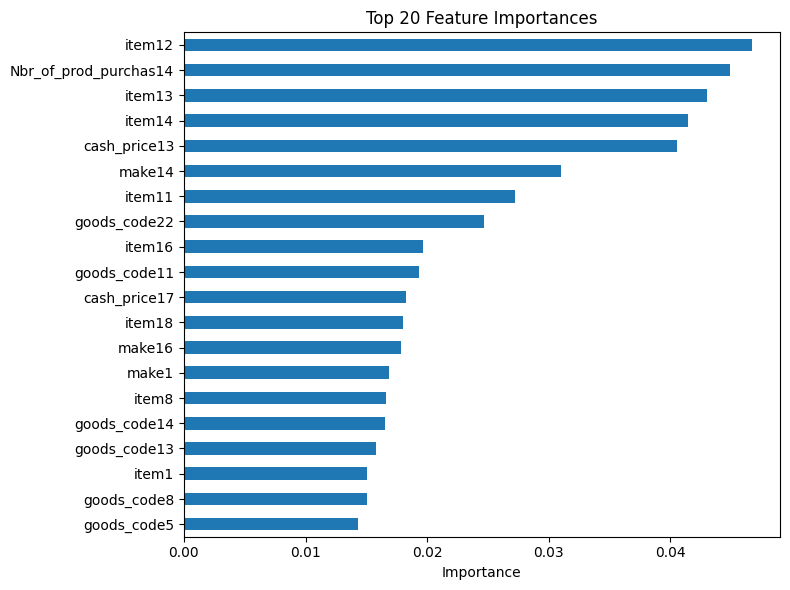

In [24]:
feature_names = numeric_cols + cat_cols

importances = pd.Series(xgb.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

print(importances.head(20))

plt.figure(figsize=(8, 6))
importances.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()